In [1]:

import pandas as pd

train_file_path = './open/train/train.csv'
market_file_path = './open/train/meta/TRAIN_전국도매_2018-2021.csv'
sanjae_file_path = './open/train/meta/TRAIN_산지공판장_2018-2021.csv'

train_df = pd.read_csv(train_file_path)
whole_df = pd.read_csv(market_file_path)
local_df = pd.read_csv(sanjae_file_path)

In [2]:
train_df.head(0)

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원)


## Applying on Train_Df

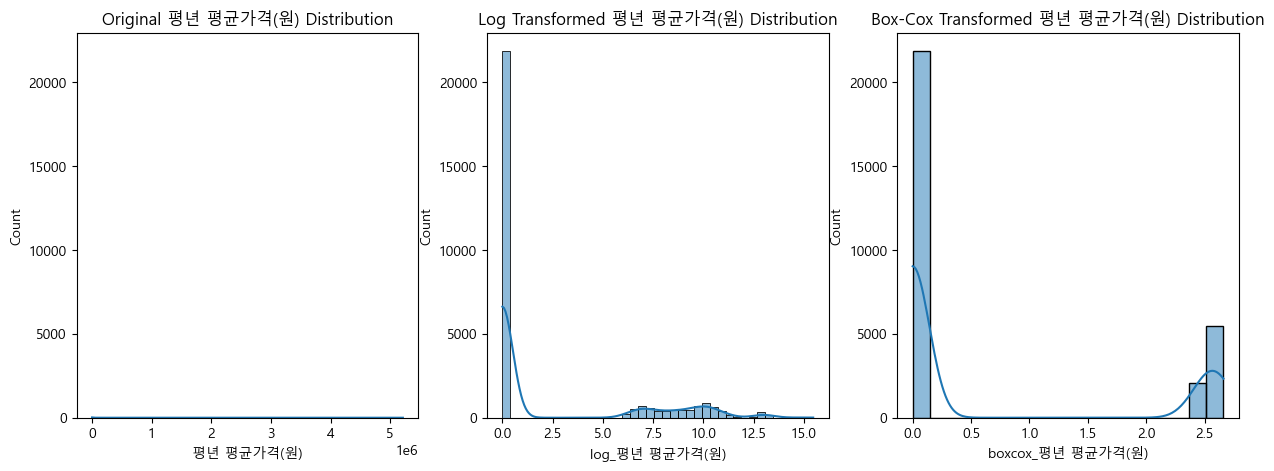

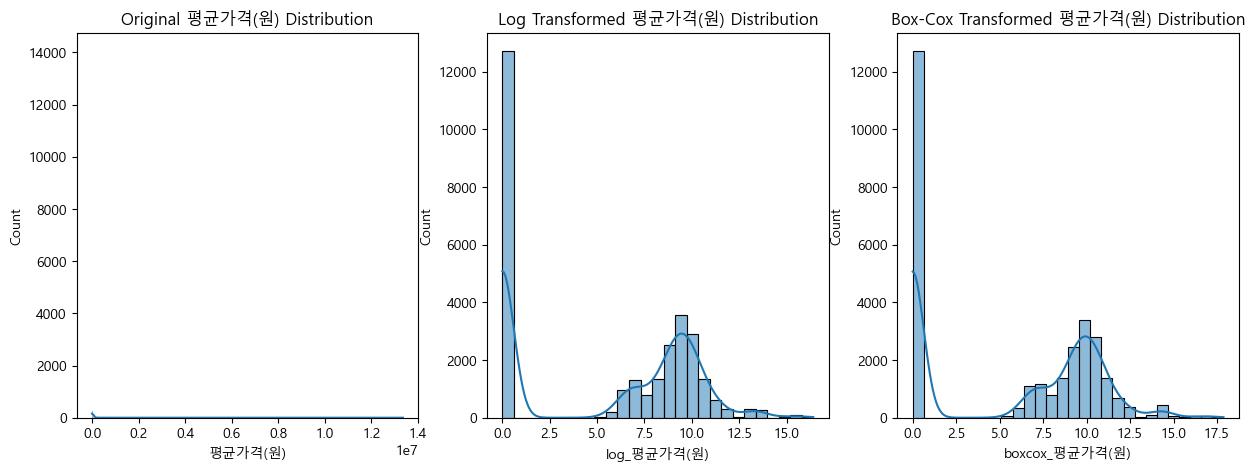

Skewness Before (평년 평균가격(원)): 21.412109702820914
Log Skewness (평년 평균가격(원)): 1.3097209590971808
Box-Cox Skewness (평년 평균가격(원)): 1.1222487292338477
Skewness Before (평균가격(원)): 16.36342523776466
Log Skewness (평균가격(원)): -0.0509557680580375
Box-Cox Skewness (평균가격(원)): -0.027036371337877257
Lambda value for 평년 평균가격(원): -0.37476280104020016
Lambda value for 평균가격(원): 0.010296396136950554


In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] ='Malgun Gothic'

# Logarithmic Transformation 
train_df['log_평년 평균가격(원)'] = np.log1p(train_df['평년 평균가격(원)'])
train_df['log_평균가격(원)'] = np.log1p(train_df['평균가격(원)'])

# Box-Cox Transformation : 양수값을 위해
train_df['boxcox_평년 평균가격(원)'], lambda_평년 = stats.boxcox(train_df['평년 평균가격(원)'] + 1)
train_df['boxcox_평균가격(원)'], lambda_평균 = stats.boxcox(train_df['평균가격(원)'] + 1)

def plot_distributions(column_name, transformed_column_log, transformed_column_boxcox):
    plt.figure(figsize=(15, 5))

    # Original 
    plt.subplot(1, 3, 1)
    sns.histplot(train_df[column_name], kde=True)
    plt.title(f'Original {column_name} Distribution')

    # Log Transformed Distribution
    plt.subplot(1, 3, 2)
    sns.histplot(train_df[transformed_column_log], kde=True)
    plt.title(f'Log Transformed {column_name} Distribution')

    # Box-Cox Transformed Distribution
    plt.subplot(1, 3, 3)
    sns.histplot(train_df[transformed_column_boxcox], kde=True)
    plt.title(f'Box-Cox Transformed {column_name} Distribution')

    plt.show()

# Plot distributions for '평년 평균가격(원)'
plot_distributions('평년 평균가격(원)', 'log_평년 평균가격(원)', 'boxcox_평년 평균가격(원)')

# Plot distributions for '평균가격(원)'
plot_distributions('평균가격(원)', 'log_평균가격(원)', 'boxcox_평균가격(원)')

# Print skewness values before and after transformations
print("Skewness Before (평년 평균가격(원)):", train_df['평년 평균가격(원)'].skew())
print("Log Skewness (평년 평균가격(원)):", train_df['log_평년 평균가격(원)'].skew())
print("Box-Cox Skewness (평년 평균가격(원)):", stats.skew(train_df['boxcox_평년 평균가격(원)']))

print("Skewness Before (평균가격(원)):", train_df['평균가격(원)'].skew())
print("Log Skewness (평균가격(원)):", train_df['log_평균가격(원)'].skew())
print("Box-Cox Skewness (평균가격(원)):", stats.skew(train_df['boxcox_평균가격(원)']))

# Print lambda values from Box-Cox transformations
print(f"Lambda value for 평년 평균가격(원): {lambda_평년}")
print(f"Lambda value for 평균가격(원): {lambda_평균}")


In [4]:
# 이상치 제거
def remove_outliers(df, column_name):
    # IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
 
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
   
    df_cleaned = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    
    return df_cleaned


train_cleaned = remove_outliers(train_df, '평년 평균가격(원)')
train_cleaned = remove_outliers(train_cleaned, '평균가격(원)')


a:\UNI\website\Prediction-of-Agricultural-Product-prices\agri-prediction\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


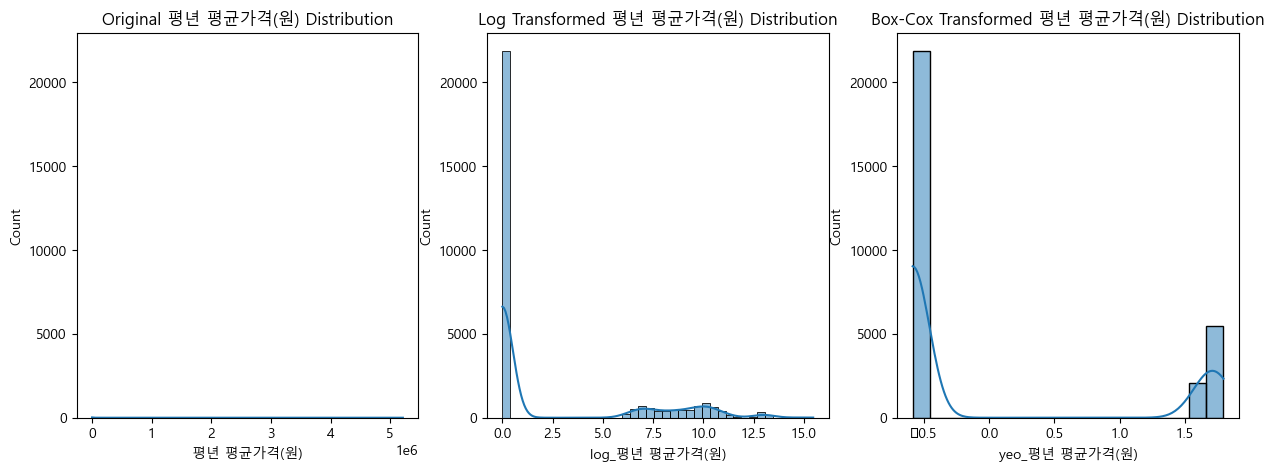

a:\UNI\website\Prediction-of-Agricultural-Product-prices\agri-prediction\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


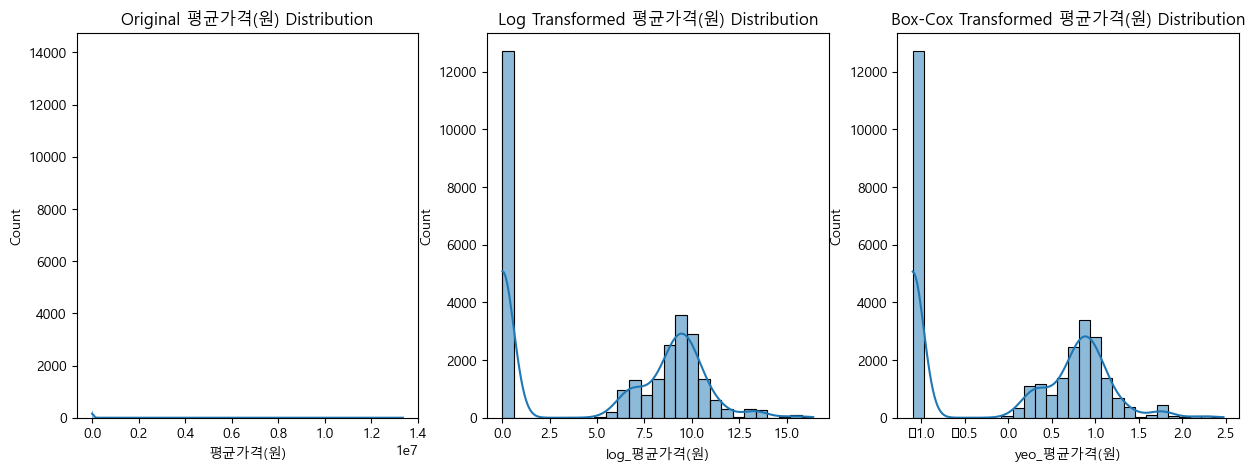

In [5]:
from sklearn.preprocessing import PowerTransformer

# Yeo-Johnson Transformation
transformer = PowerTransformer(method='yeo-johnson')

train_df['yeo_평년 평균가격(원)'] = transformer.fit_transform(train_df[['평년 평균가격(원)']])
train_df['yeo_평균가격(원)'] = transformer.fit_transform(train_df[['평균가격(원)']])

plot_distributions('평년 평균가격(원)', 'log_평년 평균가격(원)', 'yeo_평년 평균가격(원)')
plot_distributions('평균가격(원)', 'log_평균가격(원)', 'yeo_평균가격(원)')


## Applying on Whhole_df

In [6]:
whole_df.head(0)

,시점,시장코드,시장명,품목코드,품목명,품종코드,품종명,총반입량(kg),총거래금액(원),평균가(원/kg),...,저가(20%) 평균가,중간가(원/kg),최저가(원/kg),최고가(원/kg),경매 건수,전순 평균가격(원) PreVious SOON,전달 평균가격(원) PreVious MMonth,전년 평균가격(원) PreVious YeaR,평년 평균가격(원) Common Year SOON,연도


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_plot = [
    '총반입량(kg)', '총거래금액(원)', '평균가(원/kg)', '중간가(원/kg)', 
    '최저가(원/kg)', '최고가(원/kg)', 
    '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth', 
    '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON'
]

plt.figure(figsize=(20, 15))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(4, 4, i)  
    sns.histplot(whole_df[column], kde=True)
    plt.title(f'{column} Distribution')

plt.tight_layout()
plt.show()


In [3]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_transform = [
    '총반입량(kg)', '총거래금액(원)', '평균가(원/kg)', '중간가(원/kg)', 
    '최저가(원/kg)', '최고가(원/kg)', 
    '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth', 
    '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON'
]

# lambda values for each column (for Box-Cox)
lambda_values = {}

for column in columns_to_transform:
    if (whole_df[column] <= 0).any():
        whole_df[column] += 1  # Adding 1 to avoid zero or negative values
    
    # Apply Log
    whole_df[f'log_{column}'] = np.log1p(whole_df[column])  # log1p is log(1 + x) to handle zeros
    
    # Apply Box-Cox 
    whole_df[f'boxcox_{column}'], lambda_val = stats.boxcox(whole_df[column])
    lambda_values[column] = lambda_val

print("Lambda values for Box-Cox transformation:")
for col, lambda_val in lambda_values.items():
    print(f"{col}: {lambda_val}")

plt.figure(figsize=(25, 25))

for i, column in enumerate(columns_to_transform, 1):
    plt.subplot(4, 3, i)
    sns.histplot(whole_df[column], kde=True)
    plt.title(f'Original {column} Distribution')

    plt.subplot(4, 3, i + len(columns_to_transform))
    sns.histplot(whole_df[f'log_{column}'], kde=True)
    plt.title(f'Log Transformed {column} Distribution')

    plt.subplot(4, 3, i + 2*len(columns_to_transform))
    sns.histplot(whole_df[f'boxcox_{column}'], kde=True)
    plt.title(f'Box-Cox Transformed {column} Distribution')

plt.tight_layout()
plt.show()


a:\UNI\website\Prediction-of-Agricultural-Product-prices\agri-prediction\lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: Data must be positive.

In [ ]:
whole_df_cleaned = whole_df.copy()

for column in columns_to_transform:
    whole_df_cleaned = remove_outliers(whole_df_cleaned, column)

# Yeo-Johnson Transformation using PowerTransformer 
transformer = PowerTransformer(method='yeo-johnson')

for column in columns_to_transform:
    whole_df_cleaned[f'yeo_{column}'] = transformer.fit_transform(whole_df_cleaned[[column]])

plt.figure(figsize=(25, 25))

for i, column in enumerate(columns_to_transform, 1):
    # Original Data Distribution (before outlier removal and transformation)
    plt.subplot(4, 3, i)
    sns.histplot(whole_df[column], kde=True)
    plt.title(f'Original {column} Distribution')

    # Transformed Data Distribution (after outlier removal and Yeo-Johnson)
    plt.subplot(4, 3, i + len(columns_to_transform))
    sns.histplot(whole_df_cleaned[f'yeo_{column}'], kde=True)
    plt.title(f'Yeo-Johnson Transformed {column} Distribution')

plt.tight_layout()
plt.show()

## Apply on Local_df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_plot = [
    '총반입량(kg)', '총거래금액(원)', '평균가(원/kg)', '중간가(원/kg)', 
    '최저가(원/kg)', '최고가(원/kg)', 
    '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth', 
    '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON'
]

plt.figure(figsize=(20, 15))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(4, 4, i)  
    sns.histplot(local_df[column], kde=True)
    plt.title(f'{column} Distribution')

plt.tight_layout()
plt.show()


In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# lambda values for each column (for Box-Cox)
lambda_values = {}

for column in columns_to_transform:
    if (local_df[column] <= 0).any():
        local_df[column] += 1  # Adding 1 to avoid zero or negative values
    
    # Apply Log
    local_df[f'log_{column}'] = np.log1p(local_df[column])  # log1p is log(1 + x) to handle zeros
    
    # Apply Box-Cox 
    local_df[f'boxcox_{column}'], lambda_val = stats.boxcox(local_df[column])
    lambda_values[column] = lambda_val

print("Lambda values for Box-Cox transformation:")
for col, lambda_val in lambda_values.items():
    print(f"{col}: {lambda_val}")

plt.figure(figsize=(25, 25))

for i, column in enumerate(columns_to_transform, 1):
    plt.subplot(4, 3, i)
    sns.histplot(local_df[column], kde=True)
    plt.title(f'Original {column} Distribution')

    plt.subplot(4, 3, i + len(columns_to_transform))
    sns.histplot(local_df[f'log_{column}'], kde=True)
    plt.title(f'Log Transformed {column} Distribution')

    plt.subplot(4, 3, i + 2*len(columns_to_transform))
    sns.histplot(local_df[f'boxcox_{column}'], kde=True)
    plt.title(f'Box-Cox Transformed {column} Distribution')

plt.tight_layout()
plt.show()


In [ ]:
local_df_cleaned = local_df.copy()

for column in columns_to_transform:
    local_df_cleaned = remove_outliers(local_df_cleaned, column)

# Yeo-Johnson Transformation using PowerTransformer 
transformer = PowerTransformer(method='yeo-johnson')

for column in columns_to_transform:
    local_df_cleaned[f'yeo_{column}'] = transformer.fit_transform(local_df_cleaned[[column]])

plt.figure(figsize=(25, 25))

for i, column in enumerate(columns_to_transform, 1):
    # Original Data Distribution (before outlier removal and transformation)
    plt.subplot(4, 3, i)
    sns.histplot(local_df[column], kde=True)
    plt.title(f'Original {column} Distribution')

    # Transformed Data Distribution (after outlier removal and Yeo-Johnson)
    plt.subplot(4, 3, i + len(columns_to_transform))
    sns.histplot(local_df_cleaned[f'yeo_{column}'], kde=True)
    plt.title(f'Yeo-Johnson Transformed {column} Distribution')

plt.tight_layout()
plt.show()